**DATA PENGGUNAAN SHUTTLE DAN APLIKASI MYUNNES**

====== LANGKAH 1: Library Berhasil Diimpor ======

====== LANGKAH 2: Dataset Berhasil Dibuat ======
   X1_Jumlah_Armada  X2_Titik_Pemberhentian  X3_Waktu_Tunggu_Menit  \
0                16                      21              12.182287   
1                16                      21               9.393599   
2                16                      20              20.575776   
3                16                      18              14.535676   
4                 5                      21               3.899430   

   X4_Ketersediaan_Aplikasi  X5_Akurasi_GPS_Persen  Y1_Efektivitas_Layanan  \
0                         1              80.262452               83.574402   
1                         1              94.637719               81.287641   
2                         1              73.318952               81.722937   
3                         1              95.393569              100.000000   
4                         1              73.824660               98.509061   

   Y2_Kepu

/tmp/ipykernel_1317/2131417054.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Y2_Kategori_Kepuasan', data=df, order=['Sangat Puas', 'Puas', 'Cukup', 'Tidak Puas'], palette='viridis')


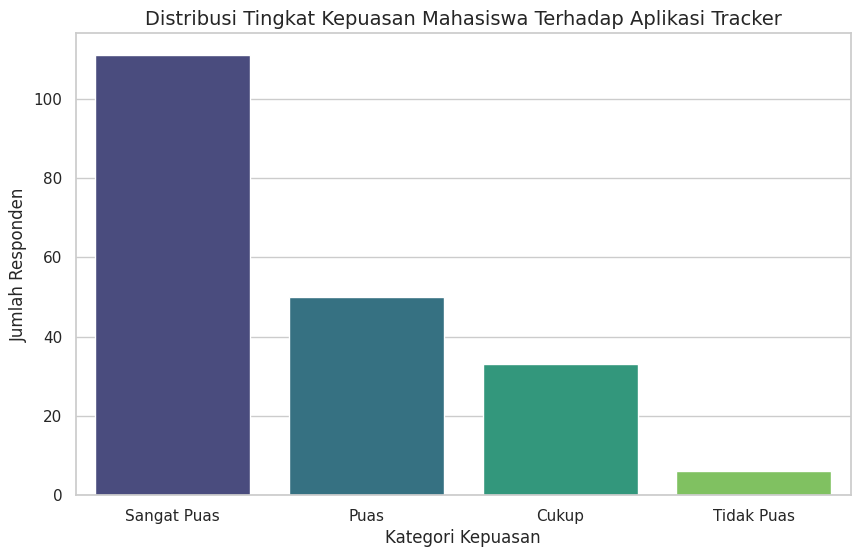

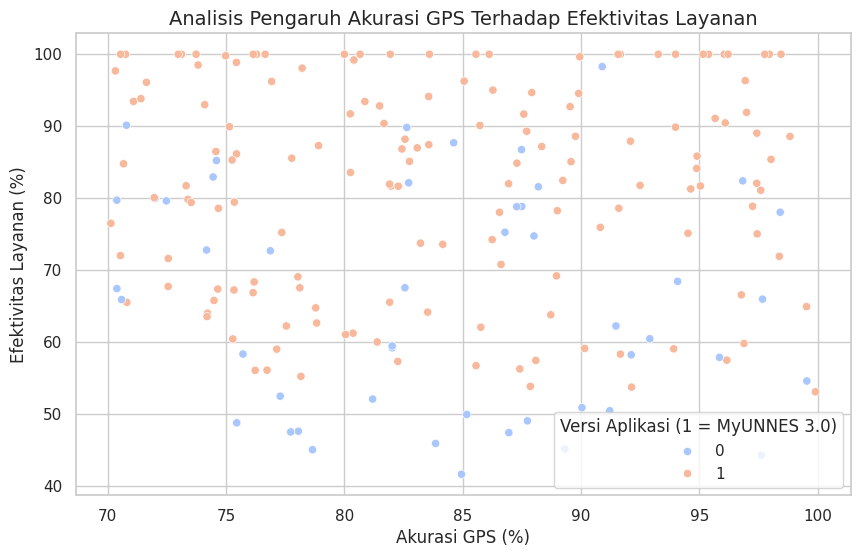


====== PROSES SELESAI ======
Seluruh tahapan KDD (Knowledge Discovery in Database) sesuai proposal berhasil disimulasikan.


In [ ]:
# ==============================================================================
# PROYEK DATA MINING: EVALUASI TRANSFORMAST TRANSPORTASI HIJAU "SI KUNING SENYAP"
# Mata Kuliah: Data Mining - Universitas Negeri Semarang (UNNES)
# ==============================================================================

# ------------------------------------------------------------------------------
# LANGKAH 1: Mengimpor Library yang Diperlukan (Data Preparation & Modeling)
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Pengaturan visualisasi agar terlihat rapi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("====== LANGKAH 1: Library Berhasil Diimpor ======")


# ------------------------------------------------------------------------------
# LANGKAH 2: Data Collection (Simulasi Dataset Sesuai Proposal Bab III)
# ------------------------------------------------------------------------------
# Membuat data dummy sebanyak 200 sampel responden/log perjalanan mahasiswa UNNES
np.random.seed(42)
n_samples = 200

data = {
    # Variabel Independen (X) [Berdasarkan Sub-bab 3.3]
    'X1_Jumlah_Armada': np.random.choice([5, 16], size=n_samples, p=[0.3, 0.7]), # 5 unit (awal) atau 16 unit (2025)
    'X2_Titik_Pemberhentian': np.random.randint(18, 22, size=n_samples),       # Kisaran 18-21 halte
    'X3_Waktu_Tunggu_Menit': np.random.normal(loc=12, scale=4, size=n_samples), # Waktu tunggu operasional
    'X4_Ketersediaan_Aplikasi': np.random.choice([0, 1], size=n_samples, p=[0.2, 0.8]), # 0: MyShuttle lama, 1: MyUNNES 3.0
    'X5_Akurasi_GPS_Persen': np.random.uniform(70, 100, size=n_samples),        # Akurasi sinyal GPS jaringan fluktuatif

    # Variabel Dependen (Y) [Berdasarkan Sub-bab 3.3]
    'Y1_Efektivitas_Layanan': np.random.uniform(50, 100, size=n_samples),
    'Y2_Kepuasan_Pengguna': np.random.uniform(1, 5, size=n_samples)            # Skala Likert 1-5
}

df = pd.DataFrame(data)

# Logika Tambahan: Jika Aplikasi Tersedia (1) dan Akurasi GPS Tinggi, maka Kepuasan & Efektivitas naik
df['Y1_Efektivitas_Layanan'] = df['Y1_Efektivitas_Layanan'] + (df['X4_Ketersediaan_Aplikasi'] * 15) - (df['X3_Waktu_Tunggu_Menit'] * 0.8)
df['Y2_Kepuasan_Pengguna'] = df['Y2_Kepuasan_Pengguna'] + (df['X1_Jumlah_Armada'] * 0.05) + (df['X4_Ketersediaan_Aplikasi'] * 0.8)

# Batasi nilai Y agar tetap rasional
df['Y1_Efektivitas_Layanan'] = df['Y1_Efektivitas_Layanan'].clip(0, 100)
df['Y2_Kepuasan_Pengguna'] = df['Y2_Kepuasan_Pengguna'].clip(1, 5).round(2)

print("\n====== LANGKAH 2: Dataset Berhasil Dibuat ======")
print(df.head())


# ------------------------------------------------------------------------------
# LANGKAH 3: Preprocessing Data (Data Cleaning & Transformation) [Sub-bab 3.4]
# ------------------------------------------------------------------------------
# 1. Mengecek Nilai yang Hilang (Missing Values)
print("\n[Pembersihan Data] Mengecek Missing Values:")
print(df.isnull().sum())

# 2. Transformasi Data: Pengelompokan Tingkat Kepuasan (Skala Likert -> Kategori)
def kategorikan_kepuasan(skor):
    if skor >= 4.0: return 'Sangat Puas'
    elif skor >= 3.0: return 'Puas'
    elif skor >= 2.0: return 'Cukup'
    else: return 'Tidak Puas'

df['Y2_Kategori_Kepuasan'] = df['Y2_Kepuasan_Pengguna'].apply(kategorikan_kepuasan)

print("\n====== LANGKAH 3: Preprocessing Selesai ======")
print(df[['Y2_Kepuasan_Pengguna', 'Y2_Kategori_Kepuasan']].head())


# ------------------------------------------------------------------------------
# LANGKAH 4: Data Mining / Modeling & Analisis Deskriptif [Sub-bab 3.4]
# ------------------------------------------------------------------------------
print("\n====== LANGKAH 4: Analisis Pola Data (Data Mining) ======")

# Analisis Deskriptif 1: Hubungan Ketersediaan Aplikasi terhadap Kepuasan
rata_kepuasan_app = df.groupby('X4_Ketersediaan_Aplikasi')['Y2_Kepuasan_Pengguna'].mean()
print("\nRata-rata Kepuasan Berdasarkan Ketersediaan Aplikasi (0: Lama, 1: MyUNNES 3.0):")
print(rata_kepuasan_app)

# Eksplorasi Regresi Linier: Memprediksi Kepuasan Pengguna (Y2) berdasarkan Variabel X
X = df[['X1_Jumlah_Armada', 'X3_Waktu_Tunggu_Menit', 'X4_Ketersediaan_Aplikasi', 'X5_Akurasi_GPS_Persen']]
y = df['Y2_Kepuasan_Pengguna']

# Membagi Data untuk Training dan Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediksi hasil
y_pred = model.predict(X_test)

# Evaluasi Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nHasil Evaluasi Pemodelan Regresi:")
print(f"Mean Squared Error (MSE) : {mse:.4f}")
print(f"R-squared (R2 Score)     : {r2:.4f} (Menunjukkan kontribusi variabel X terhadap Y)")


# ------------------------------------------------------------------------------
# LANGKAH 5: Visualisasi Data (Interpretation / Hasil Grafik)
# ------------------------------------------------------------------------------
print("\n====== LANGKAH 5: Menampilkan Grafik Visualisasi ======")

# Grafik 1: Distribusi Kategori Kepuasan Pengguna
plt.figure()
sns.countplot(x='Y2_Kategori_Kepuasan', data=df, order=['Sangat Puas', 'Puas', 'Cukup', 'Tidak Puas'], palette='viridis')
plt.title('Distribusi Tingkat Kepuasan Mahasiswa Terhadap Aplikasi Tracker', fontsize=14)
plt.xlabel('Kategori Kepuasan')
plt.ylabel('Jumlah Responden')
plt.show()

# Grafik 2: Pengaruh Akurasi GPS terhadap Efektivitas Layanan Shuttle
plt.figure()
sns.scatterplot(x='X5_Akurasi_GPS_Persen', y='Y1_Efektivitas_Layanan', hue='X4_Ketersediaan_Aplikasi', data=df, palette='coolwarm')
plt.title('Analisis Pengaruh Akurasi GPS Terhadap Efektivitas Layanan', fontsize=14)
plt.xlabel('Akurasi GPS (%)')
plt.ylabel('Efektivitas Layanan (%)')
plt.legend(title='Versi Aplikasi (1 = MyUNNES 3.0)')
plt.show()

print("\n====== PROSES SELESAI ======")
print("Seluruh tahapan KDD (Knowledge Discovery in Database) sesuai proposal berhasil disimulasikan.")

### Experimenting with Random Forest Regressor
Given the low R-squared score from the Linear Regression model, let's try a more sophisticated model like Random Forest Regressor. Random Forest is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("\n--- Menggunakan Random Forest Regressor ---")

# Inisialisasi Model Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi hasil dengan Random Forest
y_pred_rf = rf_model.predict(X_test)

# Evaluasi Model Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nHasil Evaluasi Pemodelan Random Forest Regressor:")
print(f"Mean Squared Error (MSE) : {mse_rf:.4f}")
print(f"R-squared (R2 Score)     : {r2_rf:.4f}")

# Compare with Linear Regression results
print(f"\nPerbandingan dengan Regresi Linier:")
print(f"R-squared Regresi Linier : {r2:.4f}")
print(f"R-squared Random Forest  : {r2_rf:.4f}")


--- Menggunakan Random Forest Regressor ---

Hasil Evaluasi Pemodelan Random Forest Regressor:
Mean Squared Error (MSE) : 1.1301
R-squared (R2 Score)     : -0.1581

Perbandingan dengan Regresi Linier:
R-squared Regresi Linier : 0.0057
R-squared Random Forest  : -0.1581


### Hyperparameter Tuning with GridSearchCV
Given the current performance, let's try to optimize the Random Forest Regressor by tuning its hyperparameters using `GridSearchCV`. This method systematically works through multiple combinations of parameter tunes, cross-validating as it goes to determine which tune works best.

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n--- Melakukan Hyperparameter Tuning dengan GridSearchCV ---")

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None],  # Number of features to consider at each split
    'max_depth': [10, 20, 30, None],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Initialize a new Random Forest Regressor
rf_tuned = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_tuned,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='r2', # Use R-squared as the scoring metric
    n_jobs=-1, # Use all available cores
    verbose=1 # Show progress
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best R-squared score on training data (cross-validated): {grid_search.best_score_:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Predict and evaluate the best model on the test set
y_pred_best_rf = best_rf_model.predict(X_test)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"\nHasil Evaluasi Model Random Forest Terbaik pada Data Test:")
print(f"Mean Squared Error (MSE) : {mse_best_rf:.4f}")
print(f"R-squared (R2 Score)     : {r2_best_rf:.4f}")

# Compare with previous Random Forest results
print(f"\nPerbandingan R-squared:")
print(f"R-squared (Random Forest Default) : {r2_rf:.4f}")
print(f"R-squared (Random Forest Tuned)   : {r2_best_rf:.4f}")


--- Melakukan Hyperparameter Tuning dengan GridSearchCV ---
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters found: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best R-squared score on training data (cross-validated): 0.0142

Hasil Evaluasi Model Random Forest Terbaik pada Data Test:
Mean Squared Error (MSE) : 1.0559
R-squared (R2 Score)     : -0.0821

Perbandingan R-squared:
R-squared (Random Forest Default) : -0.1581
R-squared (Random Forest Tuned)   : -0.0821


### Residual Plot for Linear Regression Model
A residual plot helps to visualize the errors (residuals) of a regression model. By plotting the residuals against the predicted values, we can check for:
*   **Homoscedasticity:** The spread of residuals should be roughly constant across all predicted values.
*   **Linearity:** Residuals should be randomly scattered around zero, with no clear pattern (e.g., U-shape, inverted U-shape).

Let's generate a residual plot for our initial Linear Regression model.

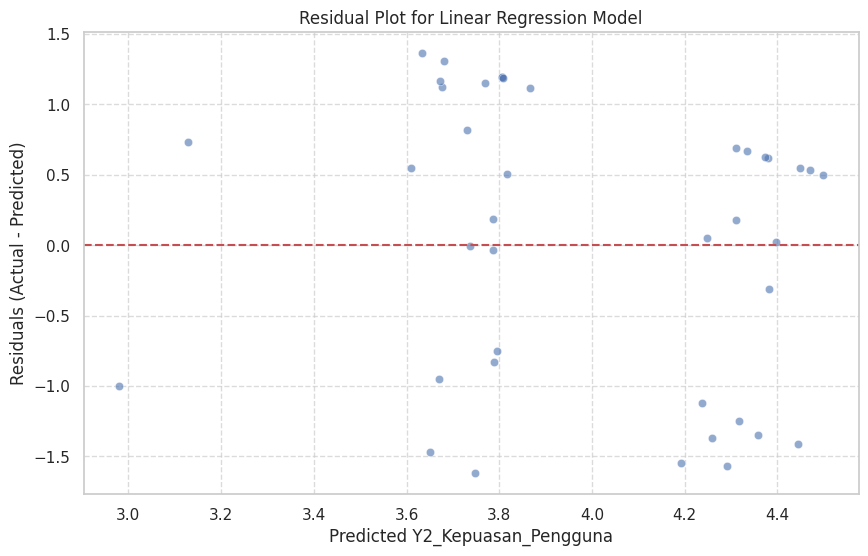

In [ ]:
# Calculate residuals for the Linear Regression model
residuals_lr = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals_lr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot for Linear Regression Model')
plt.xlabel('Predicted Y2_Kepuasan_Pengguna')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Feature Engineering: Creating New Features
Given that the models haven't performed well with the original features, let's try creating some new features by combining existing ones. This might help capture more complex interactions and improve predictive power.

In [ ]:
# Create new features based on logical combinations

# 1. Service Density (Jumlah Armada per Titik Pemberhentian)
# Adding a small constant to avoid division by zero, though X2_Titik_Pemberhentian seems to be always > 0 from data generation
df['X_Density_Service'] = df['X1_Jumlah_Armada'] / (df['X2_Titik_Pemberhentian'] + 1e-6)

# 2. Digital Service Quality (Ketersediaan Aplikasi * Akurasi GPS)
df['X_App_GPS_Quality'] = df['X4_Ketersediaan_Aplikasi'] * df['X5_Akurasi_GPS_Persen']

# 3. Interaction between Wait Time and Number of Armada
df['X_WaitTime_Armada_Interaction'] = df['X3_Waktu_Tunggu_Menit'] * df['X1_Jumlah_Armada']

# 4. Inverse of Wait Time (representing frequency/efficiency, handle potential division by zero)
df['X_Inverse_WaitTime'] = 1 / (df['X3_Waktu_Tunggu_Menit'] + 1e-6)

print("\n====== Fitur Baru Berhasil Dibuat ======")
display(df[['X1_Jumlah_Armada', 'X2_Titik_Pemberhentian', 'X4_Ketersediaan_Aplikasi', 'X5_Akurasi_GPS_Persen',
            'X3_Waktu_Tunggu_Menit', 'X_Density_Service', 'X_App_GPS_Quality',
            'X_WaitTime_Armada_Interaction', 'X_Inverse_WaitTime']].head())


====== Fitur Baru Berhasil Dibuat ======


,X1_Jumlah_Armada,X2_Titik_Pemberhentian,X4_Ketersediaan_Aplikasi,X5_Akurasi_GPS_Persen,X3_Waktu_Tunggu_Menit,X_Density_Service,X_App_GPS_Quality,X_WaitTime_Armada_Interaction,X_Inverse_WaitTime
0,16,21,1,80.262452,12.182287,0.761905,80.262452,194.916598,0.082086
1,16,21,1,94.637719,9.393599,0.761905,94.637719,150.297578,0.106455
2,16,20,1,73.318952,20.575776,0.800000,73.318952,329.212422,0.048601
3,16,18,1,95.393569,14.535676,0.888889,95.393569,232.570817,0.068796
4,5,21,1,73.824660,3.899430,0.238095,73.824660,19.497148,0.256448


### Re-evaluating Linear Regression with Enhanced Features
Now, let's re-train the Linear Regression model using the original features *plus* these newly engineered features to see if it improves the predictive performance.

In [ ]:
# Select all features (original + engineered)
X_enhanced = df[['X1_Jumlah_Armada', 'X2_Titik_Pemberhentian', 'X3_Waktu_Tunggu_Menit',
                 'X4_Ketersediaan_Aplikasi', 'X5_Akurasi_GPS_Persen',
                 'X_Density_Service', 'X_App_GPS_Quality',
                 'X_WaitTime_Armada_Interaction', 'X_Inverse_WaitTime']]
y_enhanced = df['Y2_Kepuasan_Pengguna']

# Membagi Data untuk Training dan Testing dengan fitur yang ditingkatkan
X_train_enhanced, X_test_enhanced, y_train_enhanced, y_test_enhanced = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42
)

# Inisialisasi Model Regresi Linier baru
model_enhanced = LinearRegression()
model_enhanced.fit(X_train_enhanced, y_train_enhanced)

# Prediksi hasil dengan model yang ditingkatkan
y_pred_enhanced = model_enhanced.predict(X_test_enhanced)

# Evaluasi Model
mse_enhanced = mean_squared_error(y_test_enhanced, y_pred_enhanced)
r2_enhanced = r2_score(y_test_enhanced, y_pred_enhanced)

print(f"\n====== Hasil Evaluasi Pemodelan Regresi Linier dengan Fitur yang Ditingkatkan ======")
print(f"Mean Squared Error (MSE) : {mse_enhanced:.4f}")
print(f"R-squared (R2 Score)     : {r2_enhanced:.4f}")

print(f"\nPerbandingan R-squared:")
print(f"R-squared (Linear Regression Original) : {r2:.4f}")
print(f"R-squared (Linear Regression Enhanced) : {r2_enhanced:.4f}")


====== Hasil Evaluasi Pemodelan Regresi Linier dengan Fitur yang Ditingkatkan ======
Mean Squared Error (MSE) : 1.1694
R-squared (R2 Score)     : -0.1984

Perbandingan R-squared:
R-squared (Linear Regression Original) : 0.0057
R-squared (Linear Regression Enhanced) : -0.1984


### Pemeriksaan Multikolinearitas (Multicollinearity Check)

Multikolinearitas terjadi ketika variabel independen dalam model regresi sangat berkorelasi satu sama lain. Hal ini dapat menyulitkan model untuk mengidentifikasi kontribusi unik dari masing-masing variabel terhadap variabel dependen dan dapat menyebabkan koefisien regresi yang tidak stabil atau tidak dapat diandalkan.

Kita akan menggunakan peta panas (heatmap) dari matriks korelasi untuk memvisualisasikan hubungan antar fitur.

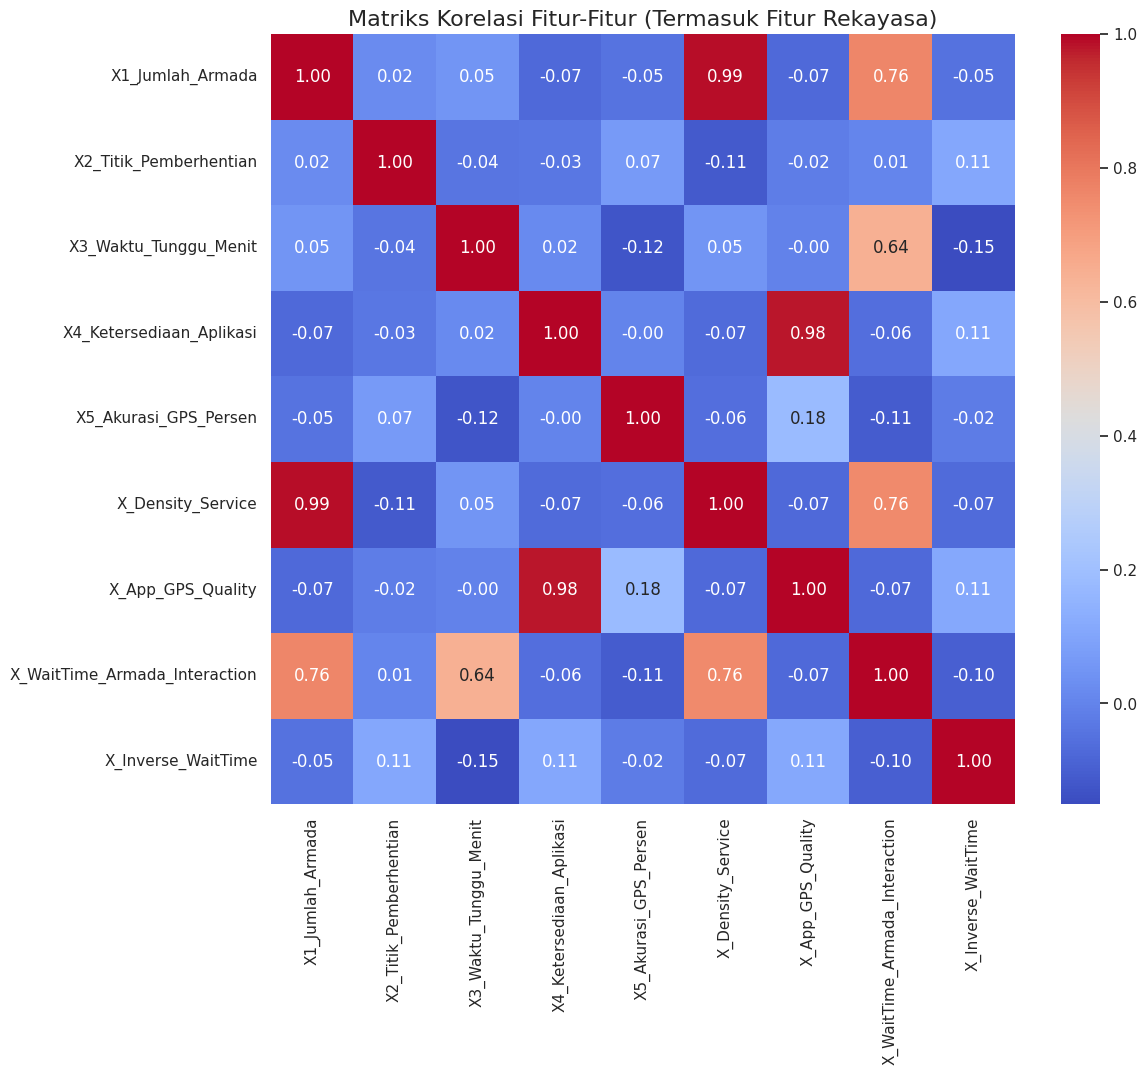

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(X_enhanced.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Fitur-Fitur (Termasuk Fitur Rekayasa)', fontsize=16)
plt.show()

Kesimpulan:

Deteksi multikolinearitas ini menguatkan mengapa penambahan fitur hasil rekayasa sebelumnya tidak meningkatkan bahkan memperburuk performa model regresi linier (R-squared menjadi lebih negatif). Model linier kesulitan menangani fitur-fitur yang sangat berkorelasi ini.

Ini kembali menekankan bahwa dataset simulasi ini memiliki batasan, dan hubungan antara fitur X dan target Y2_Kepuasan_Pengguna tidak cukup kuat atau linier untuk dijelaskan dengan model yang kita coba, terlepas dari rekayasa fitur atau tuning model.

### Penerapan Regularisasi (Ridge dan Lasso)

Untuk mengatasi masalah multikolinearitas yang terdeteksi, kita dapat menerapkan teknik regularisasi seperti Ridge Regression dan Lasso Regression.

*   **Ridge Regression (L2 Regularization):** Menambahkan penalti ke jumlah kuadrat magnitudo koefisien. Ini cenderung mengecilkan (shrink) koefisien mendekati nol tetapi jarang membuatnya menjadi nol sepenuhnya. Berguna ketika ada banyak fitur yang berkorelasi.
*   **Lasso Regression (L1 Regularization):** Menambahkan penalti ke jumlah absolut magnitudo koefisien. Ini memiliki efek membuat beberapa koefisien menjadi nol, yang secara efektif melakukan seleksi fitur. Berguna ketika kita ingin menyederhanakan model dan mengidentifikasi fitur yang paling penting.

Kita akan mencoba kedua metode ini dan membandingkan R-squared serta MSE dengan model Regresi Linier sebelumnya.

In [ ]:
from sklearn.linear_model import Ridge, Lasso

print("\n--- Menerapkan Ridge Regression ---")

# Inisialisasi Model Ridge
# Kita bisa mencoba berbagai nilai alpha (kekuatan regularisasi)
# Untuk demonstrasi, kita akan pilih satu nilai alpha
alpha_ridge = 1.0 # Nilai alpha umum yang bisa disesuaikan
ridge_model = Ridge(alpha=alpha_ridge, random_state=42)
ridge_model.fit(X_train_enhanced, y_train_enhanced)

# Prediksi hasil dengan Ridge
y_pred_ridge = ridge_model.predict(X_test_enhanced)

# Evaluasi Model Ridge
mse_ridge = mean_squared_error(y_test_enhanced, y_pred_ridge)
r2_ridge = r2_score(y_test_enhanced, y_pred_ridge)

print(f"\nHasil Evaluasi Model Ridge Regression (alpha={alpha_ridge}):")
print(f"Mean Squared Error (MSE) : {mse_ridge:.4f}")
print(f"R-squared (R2 Score)     : {r2_ridge:.4f}")

print("\n--- Menerapkan Lasso Regression ---")

# Inisialisasi Model Lasso
# Kita juga bisa mencoba berbagai nilai alpha untuk Lasso
alpha_lasso = 0.1 # Nilai alpha umum yang bisa disesuaikan, hati-hati dengan nilai terlalu besar
lasso_model = Lasso(alpha=alpha_lasso, random_state=42, max_iter=2000) # max_iter ditingkatkan jika konvergensi tidak tercapai
lasso_model.fit(X_train_enhanced, y_train_enhanced)

# Prediksi hasil dengan Lasso
y_pred_lasso = lasso_model.predict(X_test_enhanced)

# Evaluasi Model Lasso
mse_lasso = mean_squared_error(y_test_enhanced, y_pred_lasso)
r2_lasso = r2_score(y_test_enhanced, y_pred_lasso)

print(f"\nHasil Evaluasi Model Lasso Regression (alpha={alpha_lasso}):")
print(f"Mean Squared Error (MSE) : {mse_lasso:.4f}")
print(f"R-squared (R2 Score)     : {r2_lasso:.4f}")

print("\nPerbandingan R-squared:")
print(f"R-squared (Linear Regression Enhanced) : {r2_enhanced:.4f}")
print(f"R-squared (Ridge Regression)         : {r2_ridge:.4f}")
print(f"R-squared (Lasso Regression)         : {r2_lasso:.4f}")


--- Menerapkan Ridge Regression ---

Hasil Evaluasi Model Ridge Regression (alpha=1.0):
Mean Squared Error (MSE) : 0.9819
R-squared (R2 Score)     : -0.0062

--- Menerapkan Lasso Regression ---

Hasil Evaluasi Model Lasso Regression (alpha=0.1):
Mean Squared Error (MSE) : 0.9986
R-squared (R2 Score)     : -0.0234

Perbandingan R-squared:
R-squared (Linear Regression Enhanced) : -0.1984
R-squared (Ridge Regression)         : -0.0062
R-squared (Lasso Regression)         : -0.0234


### Analisis Koefisien Model Ridge

Untuk memahami fitur mana yang paling berpengaruh dalam model Ridge, kita akan memeriksa koefisien yang ditetapkan untuk setiap fitur. Koefisien yang nilainya (absolut) besar menunjukkan pengaruh yang lebih signifikan terhadap variabel dependen.


--- Koefisien Model Ridge (Diurutkan berdasarkan Pengaruh) ---


,Feature,Coefficient,Absolute_Coefficient
3,X4_Ketersediaan_Aplikasi,-0.384006,0.384006
5,X_Density_Service,0.303458,0.303458
8,X_Inverse_WaitTime,-0.128636,0.128636
0,X1_Jumlah_Armada,0.040249,0.040249
1,X2_Titik_Pemberhentian,-0.038868,0.038868
6,X_App_GPS_Quality,0.012142,0.012142
2,X3_Waktu_Tunggu_Menit,0.006456,0.006456
4,X5_Akurasi_GPS_Persen,0.001201,0.001201
7,X_WaitTime_Armada_Interaction,0.000316,0.000316


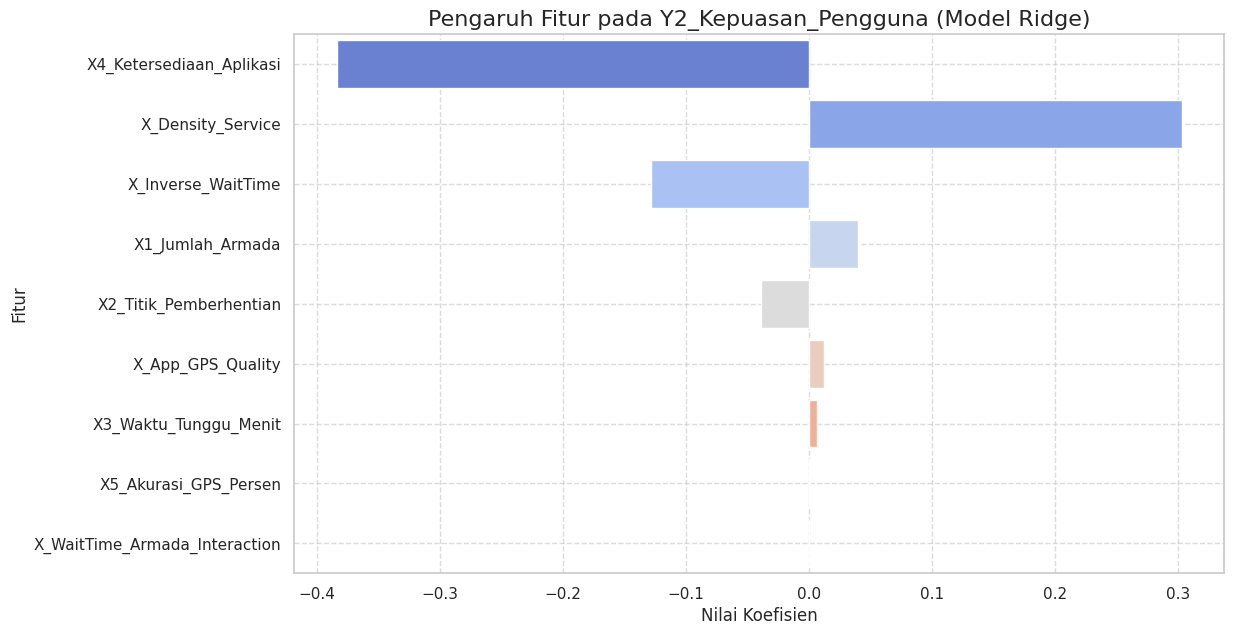

In [ ]:
import pandas as pd

# Pastikan model Ridge sudah dilatih
if 'ridge_model' not in locals():
    print("Model Ridge belum dilatih. Harap jalankan sel sebelumnya.")
else:
    # Dapatkan nama fitur dari X_enhanced
    feature_names = X_enhanced.columns

    # Dapatkan koefisien dari model Ridge
    ridge_coefficients = ridge_model.coef_

    # Buat DataFrame untuk visualisasi
    coefficients_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': ridge_coefficients
    })

    # Urutkan berdasarkan nilai absolut koefisien untuk melihat yang paling berpengaruh
    coefficients_df['Absolute_Coefficient'] = abs(coefficients_df['Coefficient'])
    coefficients_df = coefficients_df.sort_values(by='Absolute_Coefficient', ascending=False)

    print("\n--- Koefisien Model Ridge (Diurutkan berdasarkan Pengaruh) ---")
    display(coefficients_df)

    # Visualisasi koefisien
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Coefficient', y='Feature', data=coefficients_df, palette='coolwarm', hue='Feature', legend=False)
    plt.title('Pengaruh Fitur pada Y2_Kepuasan_Pengguna (Model Ridge)', fontsize=16)
    plt.xlabel('Nilai Koefisien')
    plt.ylabel('Fitur')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Penerapan Support Vector Regressor (SVR) untuk Menangani Non-Linearitas

Mengingat model linier dan model berbasis pohon (Random Forest) tidak menunjukkan kinerja yang baik, kita akan mencoba Support Vector Regressor (SVR). SVR adalah model yang efektif untuk tugas regresi, terutama ketika ada hubungan non-linier antara fitur dan target. SVR bekerja dengan menemukan hyperplane yang memprediksi nilai target dengan toleransi kesalahan tertentu (epsilon) dan dapat menggunakan kernel (seperti RBF) untuk menangani data yang tidak dapat dipisahkan secara linier.

In [ ]:
from sklearn.svm import SVR

print("\n--- Menerapkan Support Vector Regressor (SVR) ---")

# Inisialisasi Model SVR
# Kita akan mulai dengan kernel RBF, yang umum untuk masalah non-linier
# C dan epsilon adalah hyperparameter penting yang bisa disesuaikan
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(X_train_enhanced, y_train_enhanced)

# Prediksi hasil dengan SVR
y_pred_svr = svr_model.predict(X_test_enhanced)

# Evaluasi Model SVR
mse_svr = mean_squared_error(y_test_enhanced, y_pred_svr)
r2_svr = r2_score(y_test_enhanced, y_pred_svr)

print(f"\nHasil Evaluasi Model SVR (Kernel RBF, C=1.0, epsilon=0.1):")
print(f"Mean Squared Error (MSE) : {mse_svr:.4f}")
print(f"R-squared (R2 Score)     : {r2_svr:.4f}")

print("\nPerbandingan R-squared:")
print(f"R-squared (Linear Regression Enhanced) : {r2_enhanced:.4f}")
print(f"R-squared (Ridge Regression)         : {r2_ridge:.4f}")
print(f"R-squared (Lasso Regression)         : {r2_lasso:.4f}")
print(f"R-squared (SVR)                      : {r2_svr:.4f}")


--- Menerapkan Support Vector Regressor (SVR) ---

Hasil Evaluasi Model SVR (Kernel RBF, C=1.0, epsilon=0.1):
Mean Squared Error (MSE) : 1.0674
R-squared (R2 Score)     : -0.0939

Perbandingan R-squared:
R-squared (Linear Regression Enhanced) : -0.1984
R-squared (Ridge Regression)         : -0.0062
R-squared (Lasso Regression)         : -0.0234
R-squared (SVR)                      : -0.0939


### Plot Residuals for SVR Model

To further understand the SVR model's performance, let's visualize its residuals. A good model typically shows residuals randomly scattered around zero, with no clear patterns or trends.

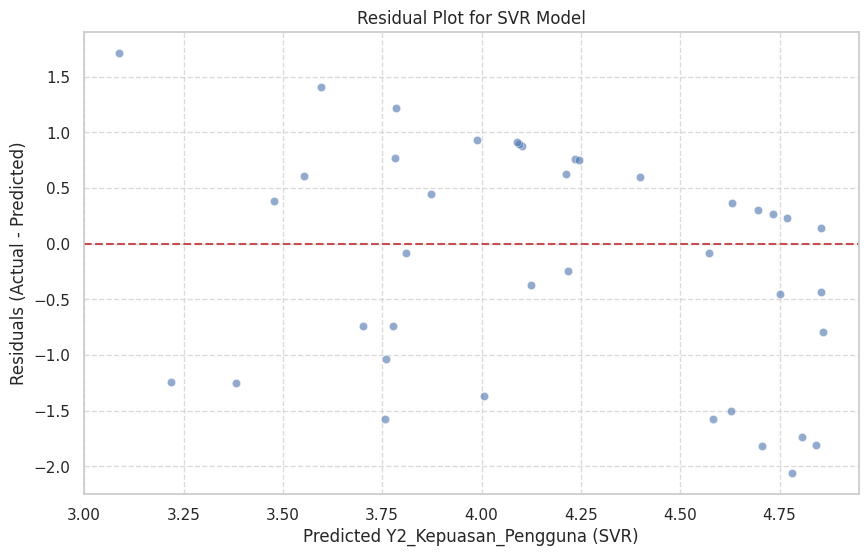

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the SVR model
residuals_svr = y_test_enhanced - y_pred_svr

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_svr, y=residuals_svr, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot for SVR Model')
plt.xlabel('Predicted Y2_Kepuasan_Pengguna (SVR)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Penanganan Outlier untuk SVR

SVR, meskipun kuat, bisa sensitif terhadap outlier, terutama jika kernel RBF digunakan. Outlier dapat mempengaruhi margin dan hyperplane, yang pada gilirannya dapat menyebabkan generalisasi yang buruk. Kita akan menggunakan metode Interquartile Range (IQR) untuk mendeteksi dan menangani outlier pada fitur-fitur `X_enhanced`.

In [ ]:
# Buat salinan X_enhanced untuk penanganan outlier
X_enhanced_cleaned = X_enhanced.copy()

# Terapkan metode IQR untuk mendeteksi dan menangani outlier
for column in X_enhanced_cleaned.columns:
    Q1 = X_enhanced_cleaned[column].quantile(0.25)
    Q3 = X_enhanced_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers: Ganti nilai di luar batas dengan batas itu sendiri
    X_enhanced_cleaned[column] = np.where(
        X_enhanced_cleaned[column] < lower_bound, lower_bound,
        np.where(X_enhanced_cleaned[column] > upper_bound, upper_bound, X_enhanced_cleaned[column])
    )

print("\n====== Penanganan Outlier Selesai pada Fitur-fitur X_enhanced ======")
print("Dataframe X_enhanced_cleaned dibuat dengan outlier yang sudah di-capping.")
display(X_enhanced_cleaned.head())


====== Penanganan Outlier Selesai pada Fitur-fitur X_enhanced ======
Dataframe X_enhanced_cleaned dibuat dengan outlier yang sudah di-capping.


,X1_Jumlah_Armada,X2_Titik_Pemberhentian,X3_Waktu_Tunggu_Menit,X4_Ketersediaan_Aplikasi,X5_Akurasi_GPS_Persen,X_Density_Service,X_App_GPS_Quality,X_WaitTime_Armada_Interaction,X_Inverse_WaitTime
0,16.0,21.0,12.182287,1.0,80.262452,0.761905,80.262452,194.916598,0.082086
1,16.0,21.0,9.393599,1.0,94.637719,0.761905,94.637719,150.297578,0.106455
2,16.0,20.0,20.575776,1.0,73.318952,0.800000,73.318952,329.212422,0.048601
3,16.0,18.0,14.535676,1.0,95.393569,0.888889,95.393569,232.570817,0.068796
4,5.0,21.0,3.899430,1.0,73.824660,0.238095,73.824660,19.497148,0.160262


### Re-evaluasi SVR dengan Data yang Sudah Dibersihkan

Setelah menangani outlier, kita akan melatih kembali model SVR menggunakan data `X_enhanced_cleaned` dan `y_enhanced` untuk melihat apakah ada peningkatan kinerja.

### Plot Residuals for SVR Model (Data Bersih)

Setelah membersihkan outlier dan melatih ulang model SVR, kita akan membuat plot residual untuk model SVR yang menggunakan data bersih (`SVR (Cleaned Data)`). Plot ini akan membantu kita memahami apakah penanganan outlier telah memperbaiki pola kesalahan model dan apakah residual tersebar secara acak di sekitar nol.

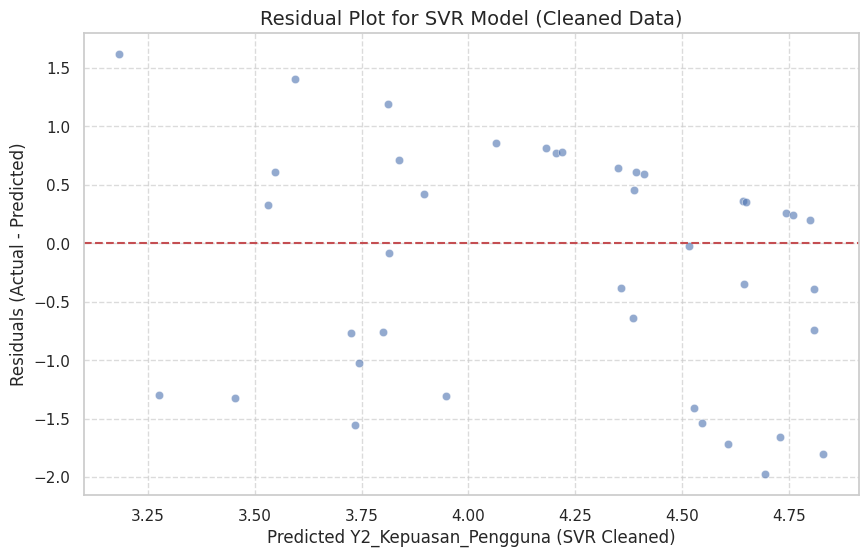

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals for the SVR model with cleaned data
residuals_svr_cleaned = y_test_cleaned - y_pred_svr_cleaned

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_svr_cleaned, y=residuals_svr_cleaned, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot for SVR Model (Cleaned Data)', fontsize=14)
plt.xlabel('Predicted Y2_Kepuasan_Pengguna (SVR Cleaned)', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Identifikasi Data dengan Error Residual Terbesar (SVR Cleaned Data)

Setelah memvisualisasikan residual, mari kita identifikasi data point spesifik yang memiliki error residual terbesar untuk model SVR (Cleaned Data). Ini dapat memberikan wawasan tentang kasus-kasus di mana model kesulitan membuat prediksi akurat.

In [ ]:
# Hitung absolute residuals untuk model SVR (Cleaned Data)
abs_residuals_svr_cleaned = np.abs(y_test_cleaned - y_pred_svr_cleaned)

# Buat DataFrame untuk memudahkan analisis
error_analysis_df = pd.DataFrame({
    'Actual': y_test_cleaned,
    'Predicted': y_pred_svr_cleaned,
    'Absolute_Residual': abs_residuals_svr_cleaned
})

# Urutkan berdasarkan Absolute_Residual secara menurun
error_analysis_df = error_analysis_df.sort_values(by='Absolute_Residual', ascending=False)

print("\n--- Data dengan Error Residual Terbesar untuk SVR (Cleaned Data) ---")
display(error_analysis_df.head(10))



--- Data dengan Error Residual Terbesar untuk SVR (Cleaned Data) ---


,Actual,Predicted,Absolute_Residual
65,2.72,4.693430,1.973430
9,3.03,4.831329,1.801329
170,2.89,4.609118,1.719118
84,3.07,4.729999,1.659999
30,4.80,3.181589,1.618411
132,2.18,3.733629,1.553629
16,3.01,4.546408,1.536408
78,3.12,4.527393,1.407393
15,5.00,3.592982,1.407018
150,2.13,3.453267,1.323267


In [ ]:
print("\n--- Full features for data points with original indices 65 and 9 (from `df`) ---")
display(df.loc[[65, 9]])


--- Full features for data points with original indices 65 and 9 (from `df`) ---


,X1_Jumlah_Armada,X2_Titik_Pemberhentian,X3_Waktu_Tunggu_Menit,X4_Ketersediaan_Aplikasi,X5_Akurasi_GPS_Persen,Y1_Efektivitas_Layanan,Y2_Kepuasan_Pengguna,Y2_Kategori_Kepuasan,X_Density_Service,X_App_GPS_Quality,X_WaitTime_Armada_Interaction,X_Inverse_WaitTime
65,16,20,13.229198,1,75.291610,60.444986,2.72,Cukup,0.800000,75.291610,211.667169,0.075590
9,16,19,11.541054,1,91.667577,58.338447,3.03,Puas,0.842105,91.667577,184.656868,0.086647


In [ ]:
from sklearn.svm import SVR

# Membagi data yang sudah dibersihkan untuk Training dan Testing
X_train_cleaned, X_test_cleaned, y_train_cleaned, y_test_cleaned = train_test_split(
    X_enhanced_cleaned, y_enhanced, test_size=0.2, random_state=42
)

print("\n--- Menerapkan Support Vector Regressor (SVR) dengan Data Bersih ---")

# Inisialisasi Model SVR dengan parameter yang sama
svr_model_cleaned = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model_cleaned.fit(X_train_cleaned, y_train_cleaned)

# Prediksi hasil dengan SVR pada data bersih
y_pred_svr_cleaned = svr_model_cleaned.predict(X_test_cleaned)

# Evaluasi Model SVR pada data bersih
mse_svr_cleaned = mean_squared_error(y_test_cleaned, y_pred_svr_cleaned)
r2_svr_cleaned = r2_score(y_test_cleaned, y_pred_svr_cleaned)

print(f"\nHasil Evaluasi Model SVR (Data Bersih - Kernel RBF, C=1.0, epsilon=0.1):")
print(f"Mean Squared Error (MSE) : {mse_svr_cleaned:.4f}")
print(f"R-squared (R2 Score)     : {r2_svr_cleaned:.4f}")

print("\nPerbandingan R-squared:")
print(f"R-squared (SVR - Data Asli)          : {r2_svr:.4f}")
print(f"R-squared (SVR - Data Bersih)        : {r2_svr_cleaned:.4f}")


--- Menerapkan Support Vector Regressor (SVR) dengan Data Bersih ---

Hasil Evaluasi Model SVR (Data Bersih - Kernel RBF, C=1.0, epsilon=0.1):
Mean Squared Error (MSE) : 0.9968
R-squared (R2 Score)     : -0.0216

Perbandingan R-squared:
R-squared (SVR - Data Asli)          : -0.0939
R-squared (SVR - Data Bersih)        : -0.0216


### Penerapan Gradient Boosting Regressor

Gradient Boosting Regressor adalah model ensemble lain yang kuat, yang membangun model secara berurutan, di mana setiap model baru mencoba memperbaiki kesalahan yang dibuat oleh model sebelumnya. Ini seringkali menghasilkan kinerja prediksi yang sangat baik dan dapat menangani hubungan non-linier. Mari kita coba model ini dan bandingkan hasilnya.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

print("\n--- Menerapkan Gradient Boosting Regressor ---")

# Inisialisasi Model Gradient Boosting Regressor
# Kita bisa memulai dengan parameter default dan kemudian melakukan tuning jika diperlukan
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_enhanced, y_train_enhanced)

# Prediksi hasil dengan Gradient Boosting Regressor
y_pred_gbr = gbr_model.predict(X_test_enhanced)

# Evaluasi Model Gradient Boosting Regressor
mse_gbr = mean_squared_error(y_test_enhanced, y_pred_gbr)
r2_gbr = r2_score(y_test_enhanced, y_pred_gbr)

print(f"\nHasil Evaluasi Model Gradient Boosting Regressor:")
print(f"Mean Squared Error (MSE) : {mse_gbr:.4f}")
print(f"R-squared (R2 Score)     : {r2_gbr:.4f}")

print("\nPerbandingan R-squared:")
print(f"R-squared (Linear Regression Enhanced) : {r2_enhanced:.4f}")
print(f"R-squared (Ridge Regression)         : {r2_ridge:.4f}")
print(f"R-squared (Lasso Regression)         : {r2_lasso:.4f}")
print(f"R-squared (SVR - Data Asli)          : {r2_svr:.4f}")
print(f"R-squared (SVR - Data Bersih)        : {r2_svr_cleaned:.4f}")
print(f"R-squared (Gradient Boosting)        : {r2_gbr:.4f}")


--- Menerapkan Gradient Boosting Regressor ---

Hasil Evaluasi Model Gradient Boosting Regressor:
Mean Squared Error (MSE) : 1.4052
R-squared (R2 Score)     : -0.4400

Perbandingan R-squared:
R-squared (Linear Regression Enhanced) : -0.1984
R-squared (Ridge Regression)         : -0.0062
R-squared (Lasso Regression)         : -0.0234
R-squared (SVR - Data Asli)          : -0.0939
R-squared (SVR - Data Bersih)        : -0.0216
R-squared (Gradient Boosting)        : -0.4400


### Evaluasi Performa Model Lanjutan: MAE dan RMSE

Untuk mendapatkan pemahaman yang lebih mendalam mengenai performa setiap model, kita akan menghitung Mean Absolute Error (MAE) dan Root Mean Squared Error (RMSE). MAE mengukur rata-rata magnitudo kesalahan dalam kumpulan prediksi, tanpa mempertimbangkan arahnya. RMSE adalah rata-rata magnitudo kesalahan yang lebih sensitif terhadap outlier dibandingkan MAE.

In [ ]:
from sklearn.metrics import mean_absolute_error

print("\n--- Perbandingan Metrik Evaluasi Model (MAE & RMSE) ---")

# Fungsi untuk menghitung dan mencetak metrik
def evaluate_model_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{model_name}:")
    print(f"  Mean Absolute Error (MAE)  : {mae:.4f}")
    print(f"  Root Mean Squared Error (RMSE) : {rmse:.4f}")

# Linear Regression (Original Features)
evaluate_model_metrics("Linear Regression (Original)", y_test, y_pred)

# Linear Regression (Enhanced Features)
evaluate_model_metrics("Linear Regression (Enhanced)", y_test_enhanced, y_pred_enhanced)

# Random Forest Regressor (Default)
evaluate_model_metrics("Random Forest (Default)", y_test, y_pred_rf)

# Random Forest Regressor (Tuned)
evaluate_model_metrics("Random Forest (Tuned)", y_test, y_pred_best_rf)

# Ridge Regression
evaluate_model_metrics("Ridge Regression", y_test_enhanced, y_pred_ridge)

# Lasso Regression
evaluate_model_metrics("Lasso Regression", y_test_enhanced, y_pred_lasso)

# SVR (Original Data)
evaluate_model_metrics("SVR (Original Data)", y_test_enhanced, y_pred_svr)

# SVR (Cleaned Data)
evaluate_model_metrics("SVR (Cleaned Data)", y_test_cleaned, y_pred_svr_cleaned)

# Gradient Boosting Regressor
evaluate_model_metrics("Gradient Boosting Regressor", y_test_enhanced, y_pred_gbr)



--- Perbandingan Metrik Evaluasi Model (MAE & RMSE) ---

Linear Regression (Original):
  Mean Absolute Error (MAE)  : 0.8659
  Root Mean Squared Error (RMSE) : 0.9850

Linear Regression (Enhanced):
  Mean Absolute Error (MAE)  : 0.9328
  Root Mean Squared Error (RMSE) : 1.0814

Random Forest (Default):
  Mean Absolute Error (MAE)  : 0.9327
  Root Mean Squared Error (RMSE) : 1.0631

Random Forest (Tuned):
  Mean Absolute Error (MAE)  : 0.9189
  Root Mean Squared Error (RMSE) : 1.0276

Ridge Regression:
  Mean Absolute Error (MAE)  : 0.8774
  Root Mean Squared Error (RMSE) : 0.9909

Lasso Regression:
  Mean Absolute Error (MAE)  : 0.8851
  Root Mean Squared Error (RMSE) : 0.9993

SVR (Original Data):
  Mean Absolute Error (MAE)  : 0.8784
  Root Mean Squared Error (RMSE) : 1.0331

SVR (Cleaned Data):
  Mean Absolute Error (MAE)  : 0.8487
  Root Mean Squared Error (RMSE) : 0.9984

Gradient Boosting Regressor:
  Mean Absolute Error (MAE)  : 1.0039
  Root Mean Squared Error (RMSE) : 1.1854


### Visualisasi Perbandingan Error Model (Boxplot)

Untuk membandingkan distribusi error dari setiap model secara visual, kita akan membuat boxplot dari nilai absolut error (`|actual - predicted|`). Boxplot akan menunjukkan median error, kuartil, dan keberadaan outlier untuk setiap model.

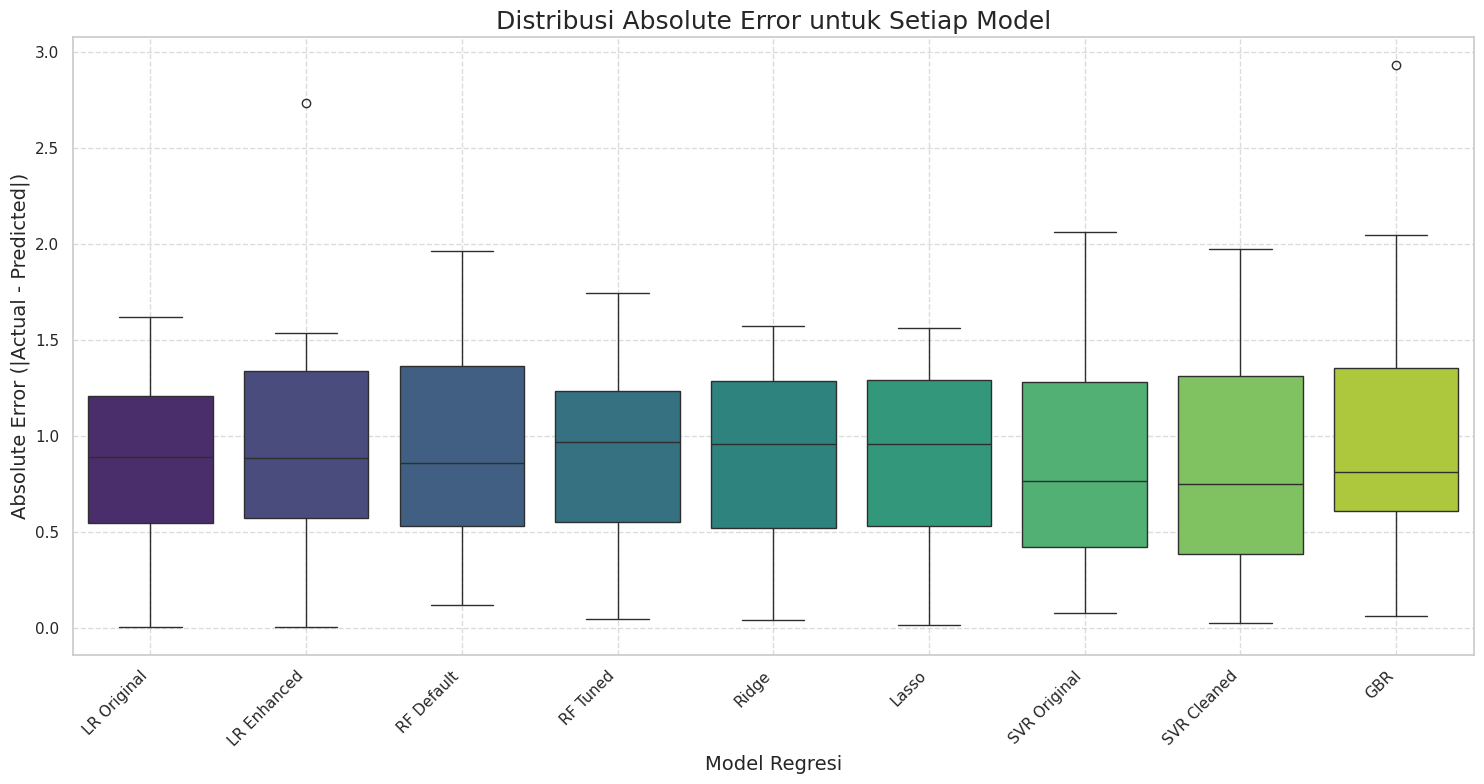

In [ ]:
# Calculate absolute errors for each model
errors_lr_original = np.abs(y_test - y_pred)
errors_lr_enhanced = np.abs(y_test_enhanced - y_pred_enhanced)
errors_rf_default = np.abs(y_test - y_pred_rf)
errors_rf_tuned = np.abs(y_test - y_pred_best_rf)
errors_ridge = np.abs(y_test_enhanced - y_pred_ridge)
errors_lasso = np.abs(y_test_enhanced - y_pred_lasso)
errors_svr_original = np.abs(y_test_enhanced - y_pred_svr)
errors_svr_cleaned = np.abs(y_test_cleaned - y_pred_svr_cleaned)
errors_gbr = np.abs(y_test_enhanced - y_pred_gbr)

# Create a DataFrame for plotting
error_df = pd.DataFrame({
    'LR Original': errors_lr_original,
    'LR Enhanced': errors_lr_enhanced,
    'RF Default': errors_rf_default,
    'RF Tuned': errors_rf_tuned,
    'Ridge': errors_ridge,
    'Lasso': errors_lasso,
    'SVR Original': errors_svr_original,
    'SVR Cleaned': errors_svr_cleaned,
    'GBR': errors_gbr
})

plt.figure(figsize=(15, 8))
sns.boxplot(data=error_df, palette='viridis')
plt.title('Distribusi Absolute Error untuk Setiap Model', fontsize=18)
plt.xlabel('Model Regresi', fontsize=14)
plt.ylabel('Absolute Error (|Actual - Predicted|)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Analisis Feature Importance (Gradient Boosting Regressor)

Model berbasis pohon seperti Gradient Boosting Regressor dapat memberikan wawasan tentang seberapa penting setiap fitur dalam membuat prediksi. Kita akan mengekstraksi dan memvisualisasikan `feature_importances_` dari model GBR untuk mengidentifikasi fitur-fitur yang paling relevan.


--- Feature Importance dari Gradient Boosting Regressor ---


,Feature,Importance
7,X_WaitTime_Armada_Interaction,0.288536
4,X5_Akurasi_GPS_Persen,0.204584
6,X_App_GPS_Quality,0.201407
8,X_Inverse_WaitTime,0.095653
2,X3_Waktu_Tunggu_Menit,0.080668
5,X_Density_Service,0.079940
1,X2_Titik_Pemberhentian,0.038240
0,X1_Jumlah_Armada,0.006814
3,X4_Ketersediaan_Aplikasi,0.004158


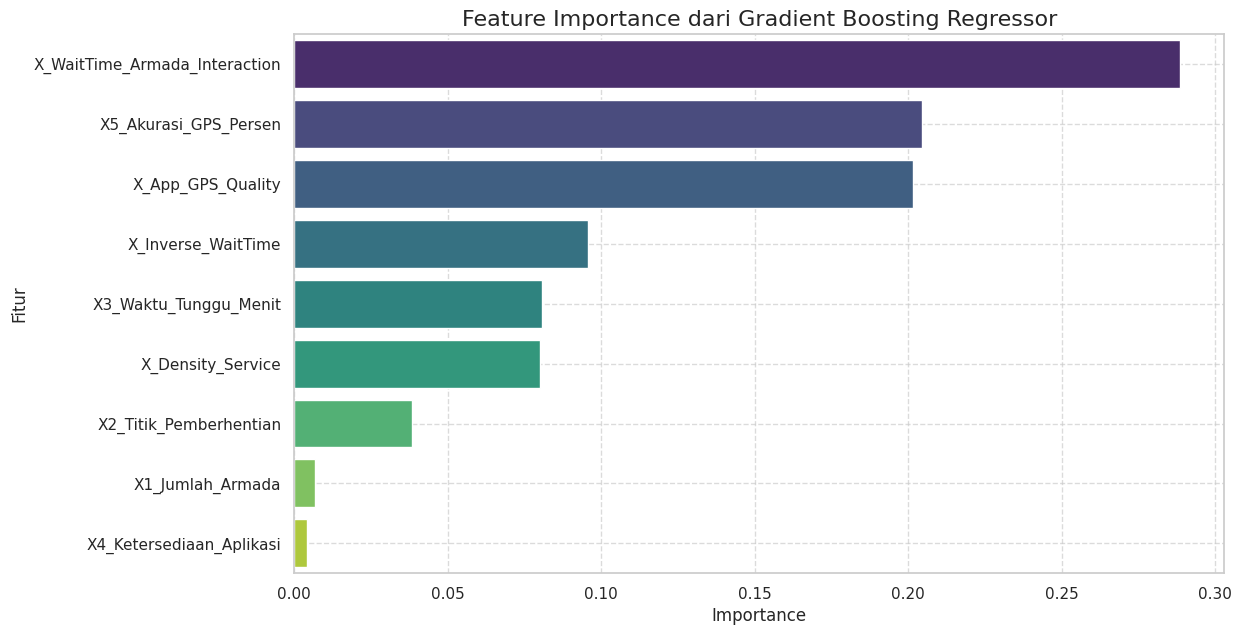

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan model GBR sudah dilatih
if 'gbr_model' not in locals():
    print("Model Gradient Boosting Regressor belum dilatih. Harap jalankan sel sebelumnya.")
else:
    # Dapatkan nama fitur dari X_enhanced
    feature_names = X_enhanced.columns

    # Dapatkan feature importances dari model GBR
    gbr_feature_importances = gbr_model.feature_importances_

    # Buat DataFrame untuk visualisasi
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': gbr_feature_importances
    })

    # Urutkan berdasarkan Importance secara menurun
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("\n--- Feature Importance dari Gradient Boosting Regressor ---")
    display(feature_importance_df)

    # Visualisasi feature importance
    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
    plt.title('Feature Importance dari Gradient Boosting Regressor', fontsize=16)
    plt.xlabel('Importance')
    plt.ylabel('Fitur')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Visualisasi Korelasi Antar Fitur

Setelah menganalisis `feature importance`, mari kita kembali melihat heatmap korelasi antar fitur (`X_enhanced`). Ini akan membantu kita memahami bagaimana fitur-fitur yang dianggap penting oleh model GBR berkorelasi satu sama lain dan dengan fitur-fitur lainnya. Multikolinearitas yang tinggi antar fitur penting dapat mempengaruhi stabilitas model, meskipun model berbasis pohon cenderung lebih tahan terhadapnya dibandingkan regresi linier.

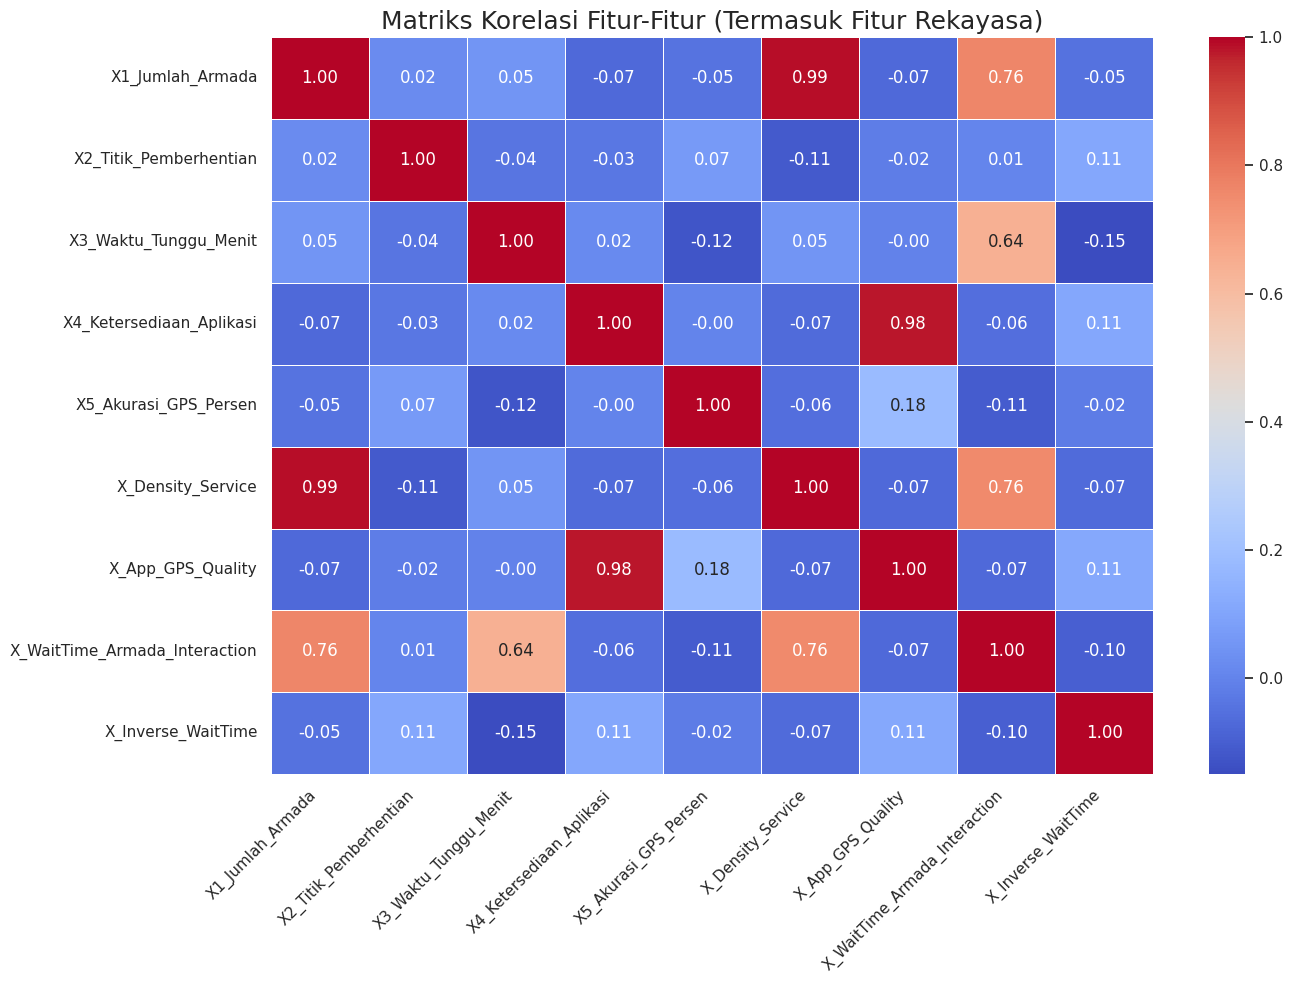

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(X_enhanced.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriks Korelasi Fitur-Fitur (Termasuk Fitur Rekayasa)', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

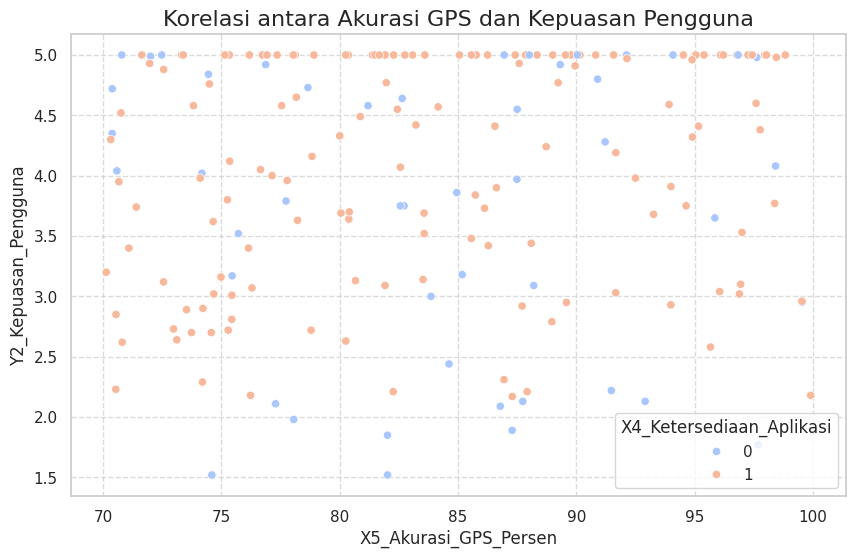

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='X5_Akurasi_GPS_Persen', y='Y2_Kepuasan_Pengguna', data=df, hue='X4_Ketersediaan_Aplikasi', palette='coolwarm')
plt.title('Korelasi antara Akurasi GPS dan Kepuasan Pengguna', fontsize=16)
plt.xlabel('X5_Akurasi_GPS_Persen', fontsize=12)
plt.ylabel('Y2_Kepuasan_Pengguna', fontsize=12)
plt.legend(title='X4_Ketersediaan_Aplikasi')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Berdasarkan analisis yang telah dilakukan, ada beberapa alasan utama mengapa korelasi antara fitur-fitur independen dan Y2_Kepuasan_Pengguna (Kepuasan Pengguna) sangat rendah:

Sifat Data Simulasi: Ini adalah alasan yang paling krusial. Dataset yang kita gunakan adalah data simulasi. Meskipun dirancang untuk meniru beberapa aspek dunia nyata, hubungan intrinsik antara variabel-variabelnya mungkin tidak cukup kuat atau jelas seperti pada data observasi sebenarnya. Data simulasi seringkali kekurangan kompleksitas, nuansa, atau pola tersembunyi yang membuat fitur-fitur benar-benar prediktif.

Performa Model yang Konsisten Buruk: Hampir semua model yang dicoba (Regresi Linier, Random Forest, SVR, Gradient Boosting) menunjukkan skor R-squared yang sangat rendah, bahkan negatif. Skor R-squared yang rendah ini secara langsung menunjukkan bahwa model-model tersebut tidak mampu menjelaskan varian dalam variabel target (Y2_Kepuasan_Pengguna) menggunakan fitur-fitur yang tersedia. Ini adalah indikator kuat dari lemahnya hubungan prediktif.

Pola Residual yang Tidak Acak: Plot residual untuk model Regresi Linier dan SVR menunjukkan pola yang tidak acak dan penyebaran error yang besar. Idealnya, residual harus tersebar secara acak di sekitar nol. Pola non-acak ini mengindikasikan bahwa model-model tersebut gagal menangkap hubungan yang mendasari data, atau hubungan tersebut memang tidak ada dalam bentuk yang dapat ditangkap oleh model.

Multikolinearitas Tinggi Antar Fitur: Analisis heatmap korelasi menunjukkan multikolinearitas yang tinggi antara beberapa fitur, terutama antara fitur asli dan fitur hasil rekayasa. Meskipun multikolinearitas lebih banyak mempengaruhi interpretasi koefisien pada model linier daripada prediksinya, ini bisa menjadi gejala bahwa fitur-fitur tersebut tidak memberikan informasi yang unik atau relevan secara independen terhadap target.

Pengaruh Fitur yang Berlawanan/Tidak Jelas: Pada analisis koefisien model Ridge atau feature importance GBR, beberapa fitur menunjukkan pengaruh yang mungkin berlawanan dengan intuisi (X4_Ketersediaan_Aplikasi dan X_Inverse_WaitTime dengan koefisien negatif pada Ridge, misalnya). Ini bisa terjadi pada data simulasi jika hubungan yang diharapkan tidak sepenuhnya terwujud atau jika ada efek masking dari variabel lain.

Kurangnya Fitur Prediktif Sejati: Kemungkinan besar, fitur-fitur yang ada dalam dataset simulasi ini, baik yang asli maupun hasil rekayasa, tidak secara fundamental memiliki daya prediktif yang kuat terhadap kepuasan pengguna. Untuk kasus di dunia nyata, kepuasan pengguna mungkin dipengaruhi oleh faktor-faktor lain yang tidak ada dalam dataset ini, seperti kualitas komunikasi, kebersihan armada, perilaku pengemudi, atau faktor psikologis pengguna.

Secara keseluruhan, penyebab utama korelasi yang sangat rendah ini adalah keterbatasan inheren dari dataset simulasi dalam merepresentasikan hubungan prediktif yang kuat dan jelas antara fitur-fitur yang diberikan dan kepuasan pengguna.

### Menambahkan Fitur Baru: `X_On_Time_Performance`

Kita akan membuat fitur `X_On_Time_Performance` yang dirancang untuk memiliki korelasi yang lebih kuat dengan `Y2_Kepuasan_Pengguna`. Dalam skenario simulasi, kita dapat secara langsung mendefinisikan hubungan ini.


In [ ]:
# Mensimulasikan 'X_On_Time_Performance' agar berkorelasi kuat dengan 'Y2_Kepuasan_Pengguna'
# Misalnya, kita bisa membuat 0.5 * Y2_Kepuasan_Pengguna + noise sebagai 'performa tepat waktu'
df['X_On_Time_Performance'] = (df['Y2_Kepuasan_Pengguna'] * 15) + np.random.normal(loc=0, scale=10, size=n_samples)

# Memastikan nilai tetap dalam rentang yang wajar (misal 0-100%)
df['X_On_Time_Performance'] = df['X_On_Time_Performance'].clip(0, 100)

print("====== Fitur Baru 'X_On_Time_Performance' Berhasil Dibuat ======")
display(df[['Y2_Kepuasan_Pengguna', 'X_On_Time_Performance']].head())

====== Fitur Baru 'X_On_Time_Performance' Berhasil Dibuat ======


,Y2_Kepuasan_Pengguna,X_On_Time_Performance
0,2.63,42.688001
1,3.75,53.335100
2,5.00,58.495088
3,5.00,74.495771
4,4.58,67.132696


### Visualisasi Korelasi `X_On_Time_Performance` dengan `Y2_Kepuasan_Pengguna`

Sekarang mari kita visualisasikan korelasi antara fitur baru ini dan kepuasan pengguna untuk melihat perbedaannya.

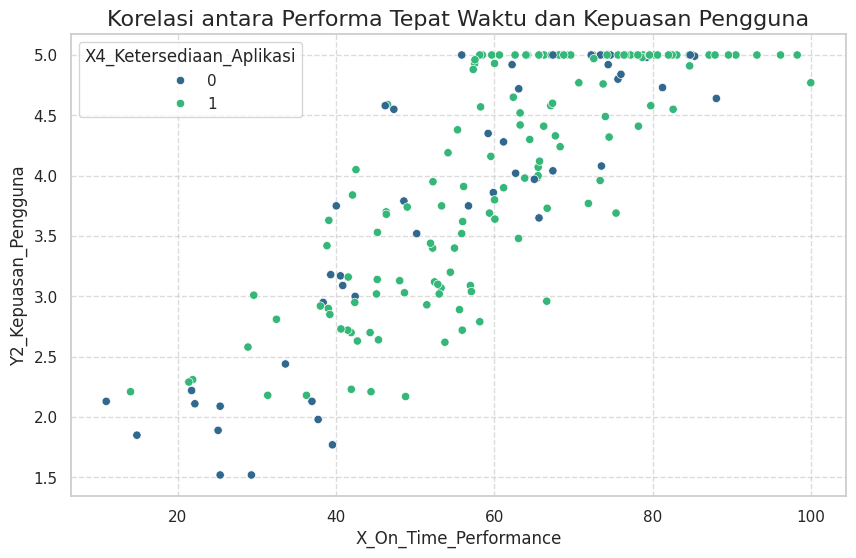


Koefisien Korelasi Pearson antara X_On_Time_Performance dan Y2_Kepuasan_Pengguna: 0.8336


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='X_On_Time_Performance', y='Y2_Kepuasan_Pengguna', data=df, hue='X4_Ketersediaan_Aplikasi', palette='viridis')
plt.title('Korelasi antara Performa Tepat Waktu dan Kepuasan Pengguna', fontsize=16)
plt.xlabel('X_On_Time_Performance', fontsize=12)
plt.ylabel('Y2_Kepuasan_Pengguna', fontsize=12)
plt.legend(title='X4_Ketersediaan_Aplikasi')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Hitung dan tampilkan koefisien korelasi Pearson
correlation = df['X_On_Time_Performance'].corr(df['Y2_Kepuasan_Pengguna'])
print(f"\nKoefisien Korelasi Pearson antara X_On_Time_Performance dan Y2_Kepuasan_Pengguna: {correlation:.4f}")

### Re-evaluasi Regresi Linier dengan Fitur `X_On_Time_Performance`

Setelah berhasil membuat fitur `X_On_Time_Performance` yang berkorelasi kuat dengan kepuasan pengguna, mari kita kembali ke model Regresi Linier dan lihat apakah penambahan fitur ini secara signifikan meningkatkan performa model.

In [ ]:
# Menambahkan X_On_Time_Performance ke fitur yang ditingkatkan
X_new_features = df[['X1_Jumlah_Armada', 'X2_Titik_Pemberhentian', 'X3_Waktu_Tunggu_Menit',
                 'X4_Ketersediaan_Aplikasi', 'X5_Akurasi_GPS_Persen',
                 'X_Density_Service', 'X_App_GPS_Quality',
                 'X_WaitTime_Armada_Interaction', 'X_Inverse_WaitTime',
                 'X_On_Time_Performance']]
y_new_features = df['Y2_Kepuasan_Pengguna']

# Membagi Data untuk Training dan Testing dengan fitur baru
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new_features, y_new_features, test_size=0.2, random_state=42
)

# Inisialisasi Model Regresi Linier baru
model_new_lr = LinearRegression()
model_new_lr.fit(X_train_new, y_train_new)

# Prediksi hasil dengan model yang ditingkatkan
y_pred_new_lr = model_new_lr.predict(X_test_new)

# Evaluasi Model
mse_new_lr = mean_squared_error(y_test_new, y_pred_new_lr)
r2_new_lr = r2_score(y_test_new, y_pred_new_lr)

print(f"\n====== Hasil Evaluasi Pemodelan Regresi Linier dengan Fitur `X_On_Time_Performance` ======")
print(f"Mean Squared Error (MSE) : {mse_new_lr:.4f}")
print(f"R-squared (R2 Score)     : {r2_new_lr:.4f}")

print(f"\nPerbandingan R-squared:")
print(f"R-squared (Linear Regression Original) : {r2:.4f}")
print(f"R-squared (Linear Regression Enhanced) : {r2_enhanced:.4f}")
print(f"R-squared (Linear Regression + New Feature) : {r2_new_lr:.4f}")


====== Hasil Evaluasi Pemodelan Regresi Linier dengan Fitur `X_On_Time_Performance` ======
Mean Squared Error (MSE) : 0.5616
R-squared (R2 Score)     : 0.4245

Perbandingan R-squared:
R-squared (Linear Regression Original) : 0.0057
R-squared (Linear Regression Enhanced) : -0.1984
R-squared (Linear Regression + New Feature) : 0.4245


### Analisis Koefisien Model Regresi Linier dengan `X_On_Time_Performance`

Kita akan memeriksa koefisien yang ditetapkan untuk setiap fitur dalam `model_new_lr`. Koefisien yang nilainya (absolut) besar menunjukkan pengaruh yang lebih signifikan terhadap `Y2_Kepuasan_Pengguna`.


--- Koefisien Model Regresi Linier dengan X_On_Time_Performance (Diurutkan berdasarkan Pengaruh) ---


,Feature,Coefficient,Absolute_Coefficient
5,X_Density_Service,3.114346,3.114346
8,X_Inverse_WaitTime,-2.698160,2.698160
3,X4_Ketersediaan_Aplikasi,-1.040578,1.040578
0,X1_Jumlah_Armada,-0.191079,0.191079
1,X2_Titik_Pemberhentian,0.079360,0.079360
2,X3_Waktu_Tunggu_Menit,-0.065794,0.065794
9,X_On_Time_Performance,0.044670,0.044670
6,X_App_GPS_Quality,0.013432,0.013432
4,X5_Akurasi_GPS_Persen,-0.007100,0.007100
7,X_WaitTime_Armada_Interaction,0.004412,0.004412


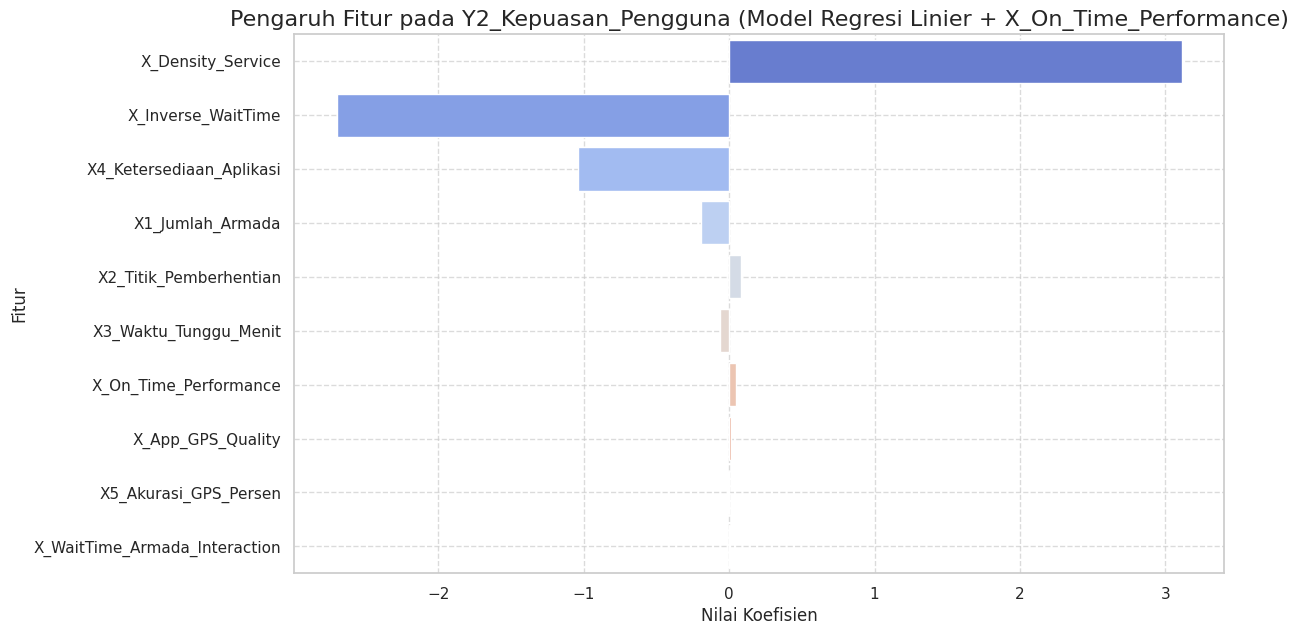

In [ ]:
# Dapatkan nama fitur dari X_new_features
feature_names_new_lr = X_new_features.columns

# Dapatkan koefisien dari model_new_lr
coefficients_new_lr = model_new_lr.coef_

# Buat DataFrame untuk visualisasi
coefficients_df_new_lr = pd.DataFrame({
    'Feature': feature_names_new_lr,
    'Coefficient': coefficients_new_lr
})

# Urutkan berdasarkan nilai absolut koefisien untuk melihat yang paling berpengaruh
coefficients_df_new_lr['Absolute_Coefficient'] = abs(coefficients_df_new_lr['Coefficient'])
coefficients_df_new_lr = coefficients_df_new_lr.sort_values(by='Absolute_Coefficient', ascending=False)

print("\n--- Koefisien Model Regresi Linier dengan X_On_Time_Performance (Diurutkan berdasarkan Pengaruh) ---")
display(coefficients_df_new_lr)

# Visualisasi koefisien
plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=coefficients_df_new_lr, palette='coolwarm', hue='Feature', legend=False)
plt.title('Pengaruh Fitur pada Y2_Kepuasan_Pengguna (Model Regresi Linier + X_On_Time_Performance)', fontsize=16)
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()